# ToolNode를 사용한 도구 사용 기능 만들기 : 계산기, 날씨, 환율도구의 도구

In [1]:
# 최근에는 모델에 툴을 바인딩하여 사용하게 하는 기능이 많이 추가되었습니다. 
# 랭그래프에서도 ToolNode라는 기능을 사용하여 LLM이 도구를 사용할 수 있습니다. 
# LLM 모델에 도구를 바인딩하여 사용자의 메시지에 따라 어떤 도구를 사용할지 결정하고, 
# 결정에 따라서 ToolNode에서 도구를 실행한 결과를 다시 LLM에게 넘긴 다음 해당 결과를 사용하여 최종 응답을 만들겠습니다. 
# 그래프의 형태는 다음 그림과 같습니다.


![](https://www.dropbox.com/scl/fi/pzb59bcijvukkgeu27io3/1014cd01-4431-4c3c-a2d5-5644953cf070.png?rlkey=3qnyp1uuhpyrq6bw290pkt4f9&st=vi75q0w9&dl=1)
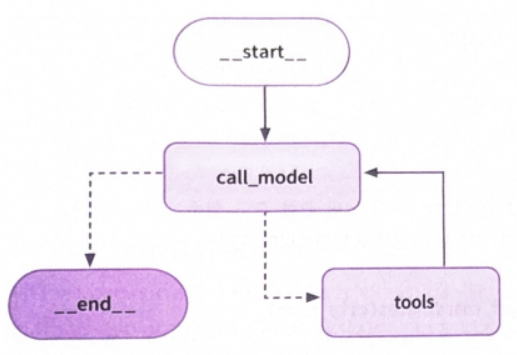

![](https://www.dropbox.com/scl/fi/1q5i0vxaf05dxxg0p3gyu/b18a554b-983f-475a-bcfd-acd0cb3d6dac.png?rlkey=3kcu744xsojkx995w5sn1p3vw&st=78mikuo6&dl=1)
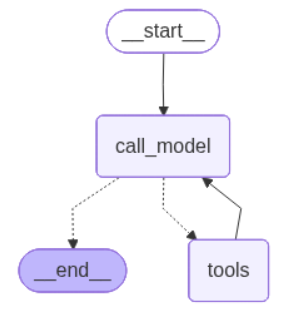

In [2]:
"""
계산기, 날씨 API, 환율 계산 도구를 만들고 도구들을 활용한 코드를 작성해봅시다. 도구들의 코드는 다음과 같습니다. 
"""
None

# 사전 학습 / Recap

In [3]:
eval("10 + 20")

30

# import

In [17]:
from dotenv import load_dotenv
print(load_dotenv())

import math
from langchain_core.messages import HumanMessage, ToolMessage
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

import FinanceDataReader as fdr
from datetime import date

True


# 사전설치 필요

In [18]:
# 설치 필요
# pip install geopy 

from geopy.geocoders import Nominatim

# Nominatim geocoding class from the geopy library. 
# 주소를 좌표(위도, 경도)  혹은 좌표를 주소로 변환해두는 geocodging 라이브러리
# This class allows developers to convert addresses into geographic coordinates (latitude and longitude) and vice versa. 

In [19]:
# http 클라이언트 라이브러리 (비동기/동기 요청 모두 가능. 사용법은 requests 와 거의 동일)
import httpx

# ToolNode
from langgraph.prebuilt import ToolNode

# 다양한 AI 모델(ChatGPT, Claude, Gemini 등)을 일관된 방식으로 쉽게 생성하고 초기화할 수 있도록 도와주는 유틸리티 함수
from langchain.chat_models import init_chat_model


# 상태 MessagesState

`MessagesState`는 LangGraph가 대화형(챗봇/에이전트) 앱을 위해 미리 만들어둔 **편의용 State 스키마**입니다. 직접 TypedDict로 `messages` 필드와 reducer를 정의하는 수고를 덜어주는 역할.

## 뭘 대신 해주나

원래 메시지 리스트를 상태로 관리하려면 이렇게 직접 작성해야 합니다:

```python
from typing import Annotated
from langgraph.graph.message import add_messages
from typing_extensions import TypedDict

class State(TypedDict):
    messages: Annotated[list, add_messages]
```

`MessagesState`는 이걸 미리 정의해둔 것뿐입니다:

```python
from langgraph.graph import MessagesState

class MessagesState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]
```

즉 `messages: Annotated[list, add_messages]` 필드 하나가 내장된 TypedDict입니다.

## `add_messages` 리듀서가 하는 일

노드가 `{"messages": [...]}`를 반환하면 기존 리스트를 **덮어쓰는 게 아니라 append** 됩니다. 게다가:
- 메시지에 `id`가 있으면 같은 id의 기존 메시지를 **업데이트(치환)**
- 없으면 새 메시지로 **추가**
- dict 형태(`{"role": "user", "content": "..."}`)도 자동으로 `HumanMessage`/`AIMessage` 등 LangChain 메시지 객체로 변환

## 사용 패턴

**그대로 쓰기:**
```python
from langgraph.graph import StateGraph, MessagesState, START, END

def call_model(state: MessagesState):
    response = llm.invoke(state["messages"])
    return {"messages": [response]}

graph = StateGraph(MessagesState)
graph.add_node("agent", call_model)
graph.add_edge(START, "agent")
graph.add_edge("agent", END)
app = graph.compile()

app.invoke({"messages": [{"role": "user", "content": "안녕"}]})
```

**필드를 추가하고 싶으면 상속:**
```python
class AgentState(MessagesState):
    user_id: str
    retrieved_docs: list[str]
```

이렇게 하면 `messages` 필드(및 리듀서)는 그대로 가져가면서 필요한 필드만 더 얹을 수 있습니다.

## 언제 직접 TypedDict를 쓰는 게 나은지

- 메시지 외 상태가 거의 없고 단순한 챗봇/에이전트 → `MessagesState` 그대로
- 메시지 관리 외에 복잡한 커스텀 리듀서, 여러 채널이 필요한 경우 → 직접 TypedDict로 세밀하게 설계하는 게 나을 수 있음
- 에이전트에 MCP 툴을 붙이는 구조라면, `MessagesState`를 상속해서 세션 정보나 도구 실행 결과 같은 필드를 추가하는 패턴이 흔히 쓰입니다.


In [20]:
# MessageState
from langgraph.graph import MessagesState


# 도구 Tools

## 계산기 도구

In [8]:
# eval() 함수 : 주어진 평가식을 실제 수행하고 계산 결과 리턴.

In [9]:
# Tool 함수의 docstring 은 LLM 에게 "이 도구가 언제 왜 어떻게 쓰여야 하는지" 를 알려주는 역할.
# ToolNode 는 docstring 을 프롬프트의 일부로 LLM 에게 전달.

In [10]:
# 계산기 도구
def calculator(expression: str) -> str:
    """수학 계산을 수행합니다."""
    print(f"계산 요청: {expression}")

    try:
        expression = expression.replace("sqrt", "math.sqrt")
        expression = expression.replace("sin", "math.sin")
        expression = expression.replace("cos", "math.cos")

        # 안전한 계산 실행
        # ※ eval() 은 파이썬 코드를 모드 실행할수 있기에, 위험한 실행동작을 예방하기 위해
        #    math 패키지만 사용하도록 제한.
        result = eval(expression, {"__builtins__": {}, "math": math})
        return f"계산 결과: {result}"
        
    except Exception as e:
        return f"💥계산 오류: {str(e)}"

In [11]:
calculator("11 * 3")

계산 요청: 11 * 3


'계산 결과: 33'

In [12]:
calculator("sin(3.14)")

계산 요청: sin(3.14)


'계산 결과: 0.0015926529164868282'

In [13]:
calculator("sqrt(2)")

계산 요청: sqrt(2)


'계산 결과: 1.4142135623730951'

## 날씨 정보 도구 함수

In [14]:
# 날씨 API
def get_weather(city_name: str) -> dict:  # 날씨 관련 도구 함수
    """도시 이름을 받아 해당 도시의 현재 날씨 정보를 반환합니다."""

    print(f"📌날씨 요청: {city_name}")
    
    if city_name:
        latitude, longitude = get_coordinates(city_name)
    else:
        raise ValueError("City name must be provided to get weather information.")    

    url = f"https://api.open-meteo.com/v1/forecast?latitude={latitude}&longitude={longitude}&current_weather=true"
    response = httpx.get(url)  # httpx 는 비동기 요청도 가능한 http 통신 라이브리러 (requrests 와 사용방법 거의 동일, requests 는 동기방식만 가능!)
    response.raise_for_status()  # HTTP 에러시 예외 발생
    return response.json()


def get_coordinates(city_name: str) -> tuple[float, float]:
    '''도시 이름을 받아 위도와 경도를 반환합니다'''
    geolocator = Nominatim(user_agent='weather_app')
    location = geolocator.geocode(city_name)
    
    if location:
        return location.latitude, location.longitude
    else:
        raise ValueError(f"Could not find coordinates for {city_name}")
    

In [15]:
get_coordinates("서울")

(37.5666791, 126.9782914)

In [16]:
get_coordinates("서울 강남구 테헤란로 146")

(37.5000198, 127.0355007)

In [17]:
get_weather("서울")

📌날씨 요청: 서울


{'latitude': 37.55,
 'longitude': 127.0,
 'generationtime_ms': 0.23233890533447266,
 'utc_offset_seconds': 0,
 'timezone': 'GMT',
 'timezone_abbreviation': 'GMT',
 'elevation': 34.0,
 'current_weather_units': {'time': 'iso8601',
  'interval': 'seconds',
  'temperature': '°C',
  'windspeed': 'km/h',
  'winddirection': '°',
  'is_day': '',
  'weathercode': 'wmo code'},
 'current_weather': {'time': '2026-09-10T07:15',
  'interval': 900,
  'temperature': 22.2,
  'windspeed': 2.7,
  'winddirection': 67,
  'is_day': 1,
  'weathercode': 1}}

## 환율 계산 도구함수

In [18]:
def currency_converter(amount: float, from_currency: str, to_currency: str) -> str:
    """통화 간 환율을 계산합니다"""
    print(f"📌{amount} {from_currency}를 {to_currency}로 변환합니다.")

    today = date.today().strftime('%Y-%m-%d') # yyyy-MM-dd
    
    try:
        df = fdr.DataReader(f'{from_currency.upper()}/{to_currency.upper()}', start=today)
        rate = df.tail(1)['Close'].item()
        converted = amount * rate
        return f"{amount} {from_currency} = {converted:.2f} {to_currency}"
    except:
        return f"{amount} {from_currency} = {amount} {to_currency} (동일 통화)"  


In [19]:
currency_converter(100, 'USD', 'KRW')

📌100 USD를 KRW로 변환합니다.


'100 USD = 134074.00 KRW'

In [20]:
currency_converter(100, 'EUR', 'KRW')

📌100 EUR를 KRW로 변환합니다.


'100 EUR = 155980.00 KRW'

In [21]:
currency_converter(100, 'JPY', 'KRW')

📌100 JPY를 KRW로 변환합니다.


'100 JPY = 871.60 KRW'

In [22]:
currency_converter(100, 'CNY', 'KRW')

📌100 CNY를 KRW로 변환합니다.


'100 CNY = 19999.50 KRW'

# 랭그래프 워크플로

## 분기 결정 시 사용하는 노드

In [23]:
# 분기 결정 시 사용하는 노드
def should_continue(state: MessagesState):
    print("\n--- 분기 결정 ---")
    last_message = state['messages'][-1]
    if last_message.tool_calls:
        print(f"결정: 🔨도구 호출 필요: ({len(last_message.tool_calls)}개)")
        return "tools"
    else:
        print("결정: 최종 응답으로 종료")
        return END


## call_model 노드를 생성하는 함수

In [24]:
# 랭그래프의 노드로 사용하려면 State 매개변수 하나만 갖고 있어야 한다.
# 추가적인 매개변수가 필요하다면, 다른 함수로 한번 감싸서 노드함수를 리턴하도록 한다


In [25]:
# call_model 노드를 생성하는 함수
def create_call_model_function(model_with_tools):  # 매개변수가 State 가 아니다!
    """model_with_tools를 클로저로 캡처하는 call_model 함수 생성"""

    def call_model(state: MessagesState):
        """LLM 을 호출하여 응답을 생성하는 노드 함수"""
        last_message = state['messages'][-1]

        # 도구 실행결과를 받았는지, 아니면 사용자 질문을 받았는지에 따라 분기
        if isinstance(last_message, ToolMessage):
            # 도구 실행 결과가 길 수 있으므로 일부만 출력
            print(f"입력(도구 결과): {last_message.content[:300]}...")
        else:
            print("\n--- 모델 호출 (사용자 질문 기반) ---")
            print(f"입력(사용자 메시지): {last_message.content}")       


        # 모델 호출하여 다음 행동을 결정하게 할거다.
        response = model_with_tools.invoke(state['messages'])

        # 모델의 결정에 따라 출력
        if response.tool_calls:
            print(f"모델의 판단: 도구 호출 -> {response.tool_calls}")
        else:
            print(f"모델의 판단: 최종 답변 생성 -> {response.content}")        

        return {"messages": [response]}  # State 업데이트 , append 된다! <- add_messages 가 동작 

    return call_model
    

## 워크플로 생성하는 함수

In [26]:
# 워크플로는 'START → call_model → [(도구를 사용해야 하면) tools call_model]-・END'가 됩니다. 

# • 유저가 메시지 입력
# • 모델에서 도구 호출이 필요한지 판단
# • 도구 호출이 필요하면 tool_node에서 도구 실행
# • 도구의 실행 결과를 받아서 모델에서 최종응답 생성
# • 최종 응답 출력


In [27]:
# 워크플로 생성하는 함수
def create_graph(model_with_tools, tool_node):
    """LLM 워크플로우 그래프 생성"""
    workflow = StateGraph(MessagesState)

    call_model = create_call_model_function(model_with_tools)
    workflow.add_node("call_model", call_model)
    workflow.add_node("tools", tool_node)

    workflow.add_edge(START, "call_model")
    workflow.add_conditional_edges(
        "call_model",
        should_continue,
        [  # list 형태로 분기 매핑 제공 가능
            "tools", END
        ],
    )
    
    workflow.add_edge("tools", "call_model")  # 도구 호출후 다시 모델 호출.
    
    return workflow.compile()
    

## 워크플로 생성 및 실행

In [34]:
# 워크플로 생성 및 실행
def llm_tool_call(query: str):
    """하나의 질문에 대해 전체 LLM 워크플로우를 실행하고 로그를 출력합니다."""
    # ⭐️ ToolNode 생성
    tools = [calculator, get_weather, currency_converter]
    tool_node = ToolNode(tools)

    # 모델 with tools
    model = init_chat_model("gpt-4o", model_provider="openai")
    model_with_tools = model.bind_tools(tools)

    print(f"질문: {query}")
    print("-" * 40)

    # LLM 기반 워크플로우 생성
    app = create_graph(model_with_tools, tool_node)

    # 워크플로우 실행
    app.invoke({"messages": [HumanMessage(content=query)]})

    # 그래프 시각화
    # display(Image(app.get_graph().draw_mermaid_png()))

    # 최종 응답은 call_model 노드의 로그에서 출력됩니다.
    print("처리완료\n")


def main():
    print("=== LangGraph ToolNode 예제 (LLM 기반) ===\n")

    test_queries = [
        # "2 + 3 * 4 를 계산해줘",   # calculator 도구 호출
        # "서울 날씨 어때?",         # get_weather 도구 호출
        # "100달러를 원화로 바꿔줘",   # currency_converter 도구 
        
        "100 * 200 을 계산해주고, 이 결과를 달러에서 원화로 바꿔줘",
    ]

    print("\nLLM 기반 도구 호출 시작:")
    
    for query in test_queries:
        try:
            llm_tool_call(query)
        except Exception as e:
            print(f"💥'{query}' 처리 중 오류 발생: {e}")
            print("\n")

if __name__ == "__main__":
    main()


=== LangGraph ToolNode 예제 (LLM 기반) ===


LLM 기반 도구 호출 시작:
질문: 100 * 200 을 계산해주고, 이 결과를 달러에서 원화로 바꿔줘
----------------------------------------

--- 모델 호출 (사용자 질문 기반) ---
입력(사용자 메시지): 100 * 200 을 계산해주고, 이 결과를 달러에서 원화로 바꿔줘
모델의 판단: 도구 호출 -> [{'name': 'calculator', 'args': {'expression': '100 * 200'}, 'id': 'call_u6lFHdh8D4AxzjCogtJ2KcVJ', 'type': 'tool_call'}, {'name': 'currency_converter', 'args': {'amount': 1, 'from_currency': 'USD', 'to_currency': 'KRW'}, 'id': 'call_ByuicDhniA4eyUw4niWOxO6s', 'type': 'tool_call'}]

--- 분기 결정 ---
결정: 🔨도구 호출 필요: (2개)
계산 요청: 100 * 200
📌1.0 USD를 KRW로 변환합니다.
입력(도구 결과): 1.0 USD = 1340.28 KRW...
모델의 판단: 최종 답변 생성 -> 100 * 200의 계산 결과는 20,000입니다. 그리고 현재 환율을 기준으로 1 달러는 1340.28 원입니다.

따라서 20,000 달러를 원화로 바꾸면 약 26,805,600 원이 됩니다.

--- 분기 결정 ---
결정: 최종 응답으로 종료
처리완료



In [ ]:
Image('06_tool_calling.png')

# 🟦 신문기사 챗봇 만들기

In [5]:
# 주제를 입력하면 챗봇이 알아서 기사를 작성하도록 해보자

In [22]:
from langchain_openai import ChatOpenAI
model = ChatOpenAI(model='gpt-4o', temperature=0.01)
model.invoke('안녕 나는 홍묵이야')

AIMessage(content='안녕하세요, 홍묵님! 만나서 반갑습니다. 어떻게 도와드릴까요?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 21, 'prompt_tokens': 15, 'total_tokens': 36, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_c9a0e786b8', 'id': 'chatcmpl-EMl4C5rQbuQl1BX8NEcINBzCPZ4Cs', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a08e3e-62a6-7141-8254-c0f4b29bf089-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 15, 'output_tokens': 21, 'total_tokens': 36, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

# 상태 정의

In [23]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph.message import add_messages

In [24]:
class State(TypedDict):
    messages: Annotated[list[str], add_messages]

# 도구 정의: @tool 사용

In [25]:
from langchain_core.tools import tool    # @tool 데코레이터
from datetime import datetime
import pytz  # 시간대 정보 (timezone) 다루기
from langchain_community.tools import DuckDuckGoSearchResults
from langchain_community.utilities import DuckDuckGoSearchAPIWrapper

import bs4
from langchain_community.document_loaders import WebBaseLoader

In [26]:
@tool
def get_current_time(timezone: str, location: str) -> str:
    """현재 시간을 반환하는 함수"""    

    try:
        tz = pytz.timezone(timezone)
        now = datetime.now(tz).strftime("%Y-%m-%d %H:%M:%S")
        result = f'{timezone} ({location}) 현재시각 {now}'
        return result
    except pytz.UnknownTimeZoneError:
        return f"알 수 없는 타임존: {timezone}"


@tool
def get_web_search(query: str, search_period: str = 'w') -> str:
    """
    웹 검색을 수행하는 함수.

    Args:
        query (str): 검색어
        search_period (str): 검색 기간 (e.g., "w" for past week (default), "m" for past month, "y" for past year, "d" for past day)

    Returns:
        str: 검색 결과
    """    

    wrapper = DuckDuckGoSearchAPIWrapper(
        time=search_period,
    )

    print('\n-------- WEB SEARCH --------')
    print(query)
    print(search_period)    

    search = DuckDuckGoSearchResults(
        api_wrapper=wrapper,
        results_separator=';\n'
    )

    result = search.invoke(query)

    for i, result in enumerate(result.split(';\n')):
        print(f'🟡 {i+1}. {result}')

    return result            


In [27]:
tools = [get_current_time, get_web_search]

In [28]:
# @tool을 이용해 '도구'로 만든 함수는 invoke()가 가능하다
get_current_time.invoke({"timezone": "Asia/Seoul", "location": "서울"})

'Asia/Seoul (서울) 현재시각 2026-09-11 11:14:10'

In [29]:
get_web_search.invoke({"query": "파이썬", "search_period": "m"})


-------- WEB SEARCH --------
파이썬
m
🟡 1. snippet: 4 days ago - Python is a high-level, general-purpose programming language that emphasizes code readability, simplicity, and ease-of-writing with the use of significant indentation, an extensive ("batteries-included") standard library, and garbage collection. Python supports multiple programming paradigms ..., title: Python (programming language) - Wikipedia, link: https://en.wikipedia.org/wiki/Python_(programming_language)
🟡 2. snippet: 1 week ago - Look up Python or python in Wiktionary, the free dictionary. ... Python (painter) (ca. 360–320 BCE), vase painter in Poseidonia · Python of Byzantium, 4th-century BCE orator, diplomat of Philip II of Macedon · Python of Catana, 4th-century BCE poet who accompanied Alexander the Great · ..., title: Python - Wikipedia, link: https://en.wikipedia.org/wiki/Python
🟡 3. snippet: 1 day ago - 2023년에 챗GPT는 제한된 경우에 수치 알고리즘을 해결하는 데 유용한 코드를 제공할 수 있었다. 한 연구에서 챗GPT는 C, C++, 파이썬, 매트랩으로 계산물리학 문제에 대한 솔루션을 생성

'snippet: 1 month ago - Python (транскр. Пајтон) је програмски језик високог нивоа опште намене. Подржава, у првом реду императивни, објектно-оријентисан и функционални стил програмирања., title: Python (програмски језик) — Википедија, link: https://sr.wikipedia.org/wiki/Python_(програмски_језик)'

In [30]:
# .name 속성도 가지게 된다

for tool in tools:
    print(tool.name)

get_current_time
get_web_search


In [31]:
get_current_time  # 정체가 StructuredTool 객체다.

StructuredTool(name='get_current_time', description='현재 시간을 반환하는 함수', args_schema=<class 'langchain_core.utils.pydantic.get_current_time'>, func=<function get_current_time at 0x16765a200>)

In [32]:
get_web_search

StructuredTool(name='get_web_search', description='웹 검색을 수행하는 함수.\n\nArgs:\n    query (str): 검색어\n    search_period (str): 검색 기간 (e.g., "w" for past week (default), "m" for past month, "y" for past year, "d" for past day)\n\nReturns:\n    str: 검색 결과', args_schema=<class 'langchain_core.utils.pydantic.get_web_search'>, func=<function get_web_search at 0x16765bf60>)

## 모델에 도구 연결

In [34]:
model_with_tools = model.bind_tools(tools)

In [35]:
# 모델 호출 수행하는 노드
def generate(state: State):
    return {"messages": model_with_tools.invoke(state['messages'])}

In [36]:
# tool 호출을 수행하는 노드
tool_node = ToolNode(tools)

# 그래프 정의

In [39]:
graph = StateGraph(State)

graph.add_node("generate", generate)
graph.add_node("tools", tool_node)

graph.add_edge(START, "generate")
graph.add_conditional_edges(
    'generate',
    lambda s: "tool_node" if s['messages'][-1].tool_calls else END,
    {
        "tool_node": "tools",
        END: END
    }
)

graph.add_edge("tools", "generate")

workflow = graph.compile()

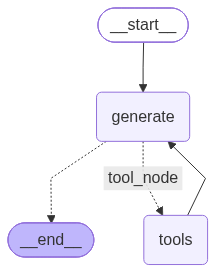

In [40]:
workflow

In [44]:
from langchain_core.messages.ai import AIMessageChunk

inputs = [HumanMessage(content="지금 서울 몇시야?")]

gathered = None

for msg, metadata in workflow.stream({"messages": inputs}, stream_mode="messages"):
    if isinstance(msg, AIMessageChunk):
        print(msg.content, end='', flush=True)
    
        if gathered is None:
            gathered = msg.content
        else:
            gathered += msg.content

지금 서울의 시간은 2026년 9월 11일 오전 11시 30분입니다.

In [45]:
gathered

'지금 서울의 시간은 2026년 9월 11일 오전 11시 30분입니다.'

# 기사 작성

In [48]:
from langchain_core.messages import SystemMessage

about = "서울월드컵 경기장 잔디 문제"

inputs = [SystemMessage(content=f"""
너는 신문기자이다. 
최근 {about}에 대해 비판하는 심층 분석 기사를 쓰려고 한다.  

- 최근 어떤 이슈가 있는지 검색하고, 사람들이 제일 관심있어 할만한 주제를 선정하고, 왜 선정했는지 말해줘. 
- 그 내용으로 원고를 작성하기 위한 목차를 만들고, 목차 내용을 채우기 위해 추가로 검색할 내용을 리스트로 정리해봐. 
- 검색할 리스트를 토대로 재검색을 한다. 
- 목차에 있는 내용을 작성하기 위해 더 검색이 필요한 정보가 있는지 확인하고, 있다면 추가로 검색해라.
- 검색된 결과에 원하는 정보를 찾지 못했다면 다른 검색어로 재검색해도 좋다. 

더 이상 검색할 내용이 없다면, 조선일보 신문 기사 형식으로 최종 기사를 작성하라.
제목, 부제, 리드문, 본문 의 구성으로 작성하라. 본문 내용은 심층 분석 기사에 맞게 구체적이고 깊이 있게 작성해야 한다. 
    
""")]


In [50]:
for msg, metadata in workflow.stream({"messages": inputs}, stream_mode="messages"):
    if isinstance(msg, AIMessageChunk):
        print(msg.content, end='', flush=True)



-------- WEB SEARCH --------
서울월드컵 경기장 잔디 문제
w
🟡 1. snippet: 4 days ago · 문체부 “내년도 개보수 지원예산 올해의 2.7배”인조잔디에 스프링클러, 풋살장에 지붕구조물 설치월드컵경기장 열어 복합문화체육공간으로 ..., title: 10년 이상 된 공공체육시설, 2500억 들여 전면 개보수한다, link: https://www.msn.com/ko-kr/도시-인프라/공용-건물-및-공간/10년-이상-된-공공체육시설-2500억-들여-전면-개보수한다/ar-AA2bGNvf
🟡 2. snippet: 3 days ago · 빅버드말고 다른 월드컵 경기장들 다 비슷하지만 지난 경기보니 잔디 상태가 너무 안좋더군요. 누더기 잔디는 이제 신경쓰이지도 않는데 땅이 쑥쑥 파여있는걸 보니 정말 위험해보이네요., title: 잔디문제는 언제쯤 개선될까요 - bluewings.me, link: https://bluewings.me/board/19162694
🟡 3. snippet: 3 days ago · 울산 원정에서 연승 행진이 멈춘 FC서울의 김기동 감독이 무득점에 대한 아쉬움을 숨기지 않았다. 서울은 8일 문수축구경기장에서 열린 울산과의 '하나은행 K리그1 2026' 28라운드 원정경기에서 후반 38분 심상민에게 결승골을 헌납하며 0대1로 패했다., title: [현장인터뷰]"욕심부리지 말라고 했더니…" 무득점에 한숨 내쉰 김기동..., link: https://www.sportschosun.com/football/2026-09-08/202609080100059830003862
🟡 4. snippet: 3 days ago · 한눈에 보는 오늘 : 축구 - 뉴스 : 울산-김태석 기자김기동 FC 서울 감독이 울산 HD FC전 패배에 대해 아쉬움을 표했다. 또한 경기가 벌어진 울산 문수축구경기장의 잔디 상태에 대해서도 우려를 나타냈다.김 감독이 지휘하는 서울은 8일 저녁 7시 30분 울산 문수축구경기, title: [B11 현장] 